<a href="https://colab.research.google.com/github/fds-imane/Data_Marketing/blob/main/data_marketing_part_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:

# TP5 — Étape 1 : Exploration des parcours

# Manipulation de données
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt

# Encodage des séquences (pour visualisation haute dimension)
from sklearn.preprocessing import MultiLabelBinarizer

# Réduction de dimension
from sklearn.manifold import TSNE

#### Chargement et préparation des données

In [18]:

# 1. Chargement des données

# Lecture du fichier CSV contenant les touchpoints
touchpoints = pd.read_csv("touchpoints_cleaned.csv")

# Conversion de la colonne timestamp en format datetime
touchpoints["timestamp"] = pd.to_datetime(
    touchpoints["timestamp"],
    errors="coerce"  # met NaT si format invalide
)

# Tri des données par client puis par ordre chronologique
touchpoints = touchpoints.sort_values(
    ["customer_id", "timestamp"]
).reset_index(drop=True)

# Aperçu rapide
touchpoints.head()

,touchpoint_id,customer_id,invoice_id,campaign_name,timestamp,channel,position,n_touchpoints,click,converted,cost,is_last_before_conversion
0,0,12346,NaN,Summer_Sale,2011-01-12 13:53:03.779455317,affiliate,1,6,1,0,1.8698,0
1,1,12346,NaN,Summer_Sale,2011-01-13 09:39:01.945606194,social,2,6,0,0,0.9344,0
2,2,12346,NaN,Summer_Sale,2011-01-15 12:26:06.292806500,direct,3,6,1,0,0.0000,0
3,3,12346,NaN,Summer_Sale,2011-01-16 04:17:18.063426214,affiliate,4,6,1,0,1.8373,0
4,4,12346,NaN,Summer_Sale,2011-01-16 13:03:11.985655755,social,5,6,0,0,0.5099,0


Nombre de touchpoints par client

In [19]:
# 2. Nombre de touchpoints par client
# Calcul du nombre de points de contact par client
path_lengths = (
    touchpoints
    .groupby("customer_id")
    .size()
    .rename("path_length")
    .reset_index()
)

# Calcul de la moyenne
avg_touchpoints = path_lengths["path_length"].mean()

print(f"\nTouchpoints moyens par client : {avg_touchpoints:.2f}")


Touchpoints moyens par client : 14.48


Distribution des longueurs de parcours

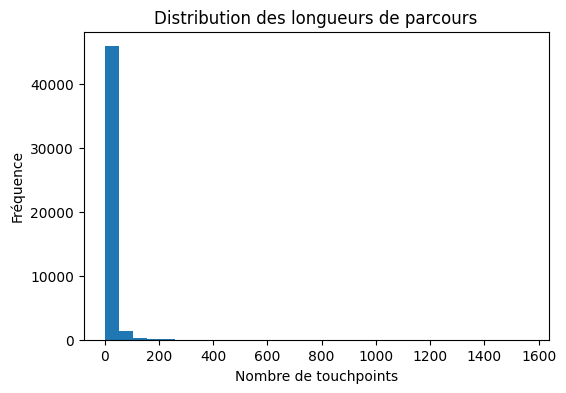

In [20]:

# Distribution des longueurs de parcours

plt.figure(figsize=(6,4))

# Histogramme du nombre de touchpoints
plt.hist(path_lengths["path_length"], bins=30)

plt.title("Distribution des longueurs de parcours")
plt.xlabel("Nombre de touchpoints")
plt.ylabel("Fréquence")

plt.show()

#### Durée des parcours


In [21]:

# 3. Durée moyenne des parcours

def compute_duration(group):
    """
    Calcule la durée du parcours client en jours.

    Logique :
    - Début = premier touchpoint
    - Si conversion :
        fin = dernier touchpoint avant conversion
    - Sinon :
        fin = dernier touchpoint observé
    """

    start = group["timestamp"].min()

    # Si le client a converti
    if group["converted"].max() == 1:
        end_candidates = group.loc[
            group["is_last_before_conversion"] == 1,
            "timestamp"
        ]

        # fallback si le flag est mal renseigné
        end = end_candidates.max() if len(end_candidates) > 0 else group["timestamp"].max()
    else:
        end = group["timestamp"].max()

    # Durée en jours
    return (end - start).total_seconds() / 86400


# Application par client
durations = (
    touchpoints
    .groupby("customer_id")[["timestamp", "converted", "is_last_before_conversion"]]
    .apply(compute_duration)
    .rename("duration_days")
    .reset_index()
)

# Moyenne
avg_duration = durations["duration_days"].mean()

print(f"Durée moyenne du parcours (jours) : {avg_duration:.2f}")

Durée moyenne du parcours (jours) : 145.99


Canaux first-touch


In [22]:

# 4. Canaux first-touch

# Premier canal rencontré par chaque client
first_touch = (
    touchpoints
    .groupby("customer_id")
    .first()["channel"]
    .value_counts()
)

print("\nTop canaux en première position :")
print(first_touch.head(10))


Top canaux en première position :
channel
display        12950
social         12866
affiliate      12753
email           4669
retargeting     4596
Name: count, dtype: int64


Dernier canal avant conversion


In [23]:

# 5. Dernier canal avant conversion

# On filtre uniquement les touchpoints marqués
# comme dernier avant conversion
last_touch = (
    touchpoints[
        touchpoints["is_last_before_conversion"] == 1
    ]["channel"]
    .value_counts()
)

print("\nTop canaux en dernière position avant conversion :")
print(last_touch.head(10))


Top canaux en dernière position avant conversion :
channel
retargeting    24990
email          24777
direct         24693
search_paid    24636
Name: count, dtype: int64


Séquences de canaux récurrentes

In [24]:

# 6. Séquences de canaux récurrentes

# Reconstruction des parcours sous forme de chaînes
top_sequences = (
    touchpoints
    .groupby("customer_id")["channel"]
    .apply(lambda x: " → ".join(x))
    .value_counts()
    .head(10)
)

print("\nSéquences de canaux les plus fréquentes :")
print(top_sequences)


Séquences de canaux les plus fréquentes :
channel
display                    522
affiliate                  516
social                     508
email                      353
retargeting                350
display → email            213
social → retargeting       208
social → email             202
affiliate → retargeting    200
display → display          193
Name: count, dtype: int64


t-SNE (visualisation haute dimension — bonus EDA)


--- t-SNE des parcours ---
Shape matrice encodée : (47834, 7)


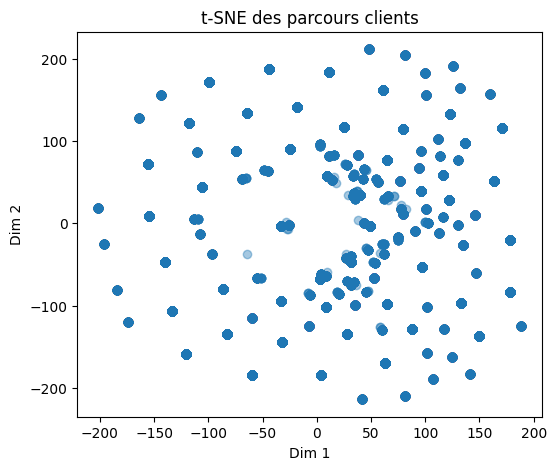

In [26]:

# PARTIE BONUS — Visualisation haute dimension (t-SNE)

print("\n--- t-SNE des parcours ---")


# Construction des séquences par client

seq_df = (
    touchpoints
    .groupby("customer_id")["channel"]
    .apply(list)
    .reset_index()
)


# Encodage multi-hot des canaux

mlb = MultiLabelBinarizer()
X = mlb.fit_transform(seq_df["channel"])

print("Shape matrice encodée :", X.shape)


# Réduction de dimension avec t-SNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca"
)

X_embedded = tsne.fit_transform(X)


# Visualisation

plt.figure(figsize=(6,5))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], alpha=0.4)

plt.title("t-SNE des parcours clients")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")

plt.show()

#### Préparation du DataFrame d'Attribution

In [ ]:
# On ne garde que les clients qui ont converti
df_conv = touchpoints[touchpoints['converted'] == 1].copy()

# On s'assure que les touchpoints sont triés par ordre chronologique
df_conv = df_conv.sort_values(['customer_id', 'timestamp'])

# On calcule la position relative dans le parcours
df_conv['position_in_path'] = df_conv.groupby('customer_id').cumcount() + 1
df_conv['path_length'] = df_conv.groupby('customer_id')['touchpoint_id'].transform('count')

print(" Données de conversion prêtes pour l'attribution.")

#### Calcul des 4 modèles heuristiques

In [32]:
import numpy as np
# 1. First Touch : 100% au premier clic
df_conv['attr_first_touch'] = np.where(df_conv['position_in_path'] == 1, 1, 0)

# 2. Last Touch : 100% au dernier clic
df_conv['attr_last_touch'] = np.where(df_conv['position_in_path'] == df_conv['path_length'], 1, 0)

# 3. Linéaire : 1 / Longueur du parcours pour chaque étape
df_conv['attr_linear'] = 1 / df_conv['path_length']

# 4. Position-Based (U-Shape) : 40% au premier, 40% au dernier, 20% répartis au milieu
def u_shape_attr(row):
    if row['path_length'] == 1: return 1.0
    if row['path_length'] == 2: return 0.5
    if row['position_in_path'] == 1 or row['position_in_path'] == row['path_length']:
        return 0.4
    else:
        return 0.2 / (row['path_length'] - 2)

df_conv['attr_u_shape'] = df_conv.apply(u_shape_attr, axis=1)

print("Modèles heuristiques calculés")

Modèles heuristiques calculés


#### Comparaison et Visualisation

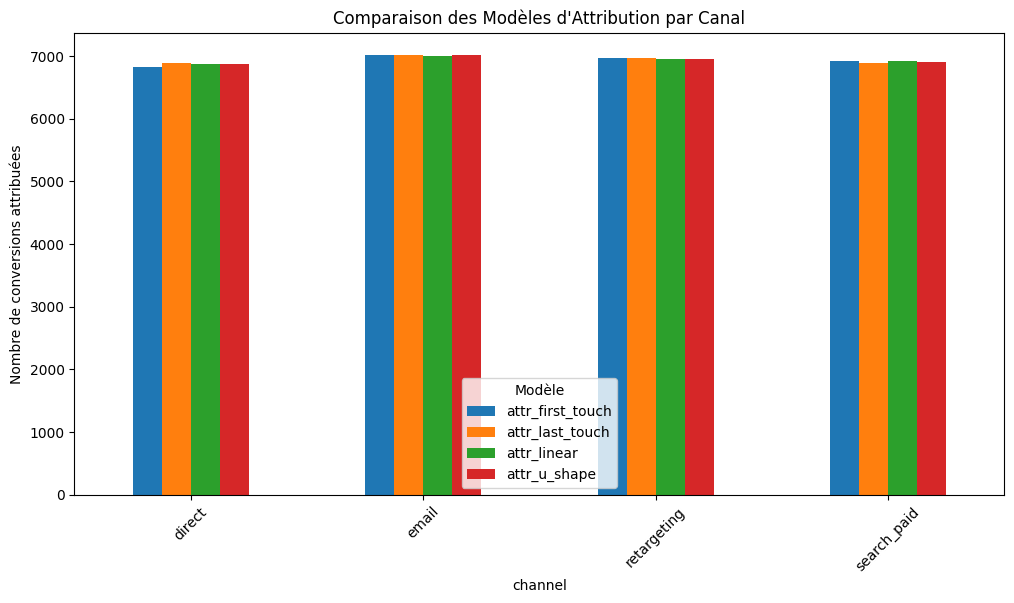

In [33]:
# Agrégation par canal
attr_cols = ['attr_first_touch', 'attr_last_touch', 'attr_linear', 'attr_u_shape']
attribution_results = df_conv.groupby('channel')[attr_cols].sum()

# Visualisation
attribution_results.plot(kind='bar', figsize=(12, 6))
plt.title('Comparaison des Modèles d\'Attribution par Canal')
plt.ylabel('Nombre de conversions attribuées')
plt.xticks(rotation=45)
plt.legend(title='Modèle')
plt.show()

#### Modèle de Markov

In [39]:

# CELLULE 1 : PRÉPARATION DES DONNÉES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# 1. On identifie les clients ayant converti
converted_customers = touchpoints[touchpoints['converted'] == 1]['customer_id'].unique()

# 2. On récupère tout l'historique de ces clients spécifiques
df_conv = touchpoints[touchpoints['customer_id'].isin(converted_customers)].copy()

# 3. On trie par client et par ordre chronologique
df_conv = df_conv.sort_values(['customer_id', 'timestamp'])

# 4. On calcule la position de chaque clic dans le parcours
df_conv['position_in_path'] = df_conv.groupby('customer_id').cumcount() + 1
df_conv['path_length'] = df_conv.groupby('customer_id')['touchpoint_id'].transform('count')

print(f" Données prêtes : {len(converted_customers)} clients convertis isolés.")

 Données prêtes : 27753 clients convertis isolés.


#### Modèles heuristiques

Modèles heuristiques calculés.


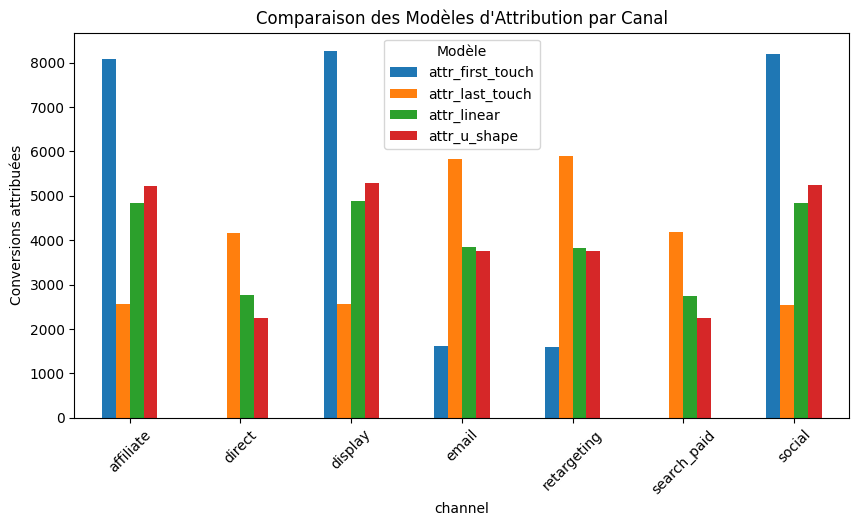

In [40]:

# CELLULE 2 : MODÈLES HEURISTIQUES
# 1. First Touch : 100% au premier clic
df_conv['attr_first_touch'] = np.where(df_conv['position_in_path'] == 1, 1, 0)

# 2. Last Touch : 100% au dernier clic
df_conv['attr_last_touch'] = np.where(df_conv['position_in_path'] == df_conv['path_length'], 1, 0)

# 3. Linéaire : 1 / Longueur totale du parcours
df_conv['attr_linear'] = 1 / df_conv['path_length']

# 4. Position-Based (U-Shape)
def u_shape_attr(row):
    if row['path_length'] == 1: return 1.0
    if row['path_length'] == 2: return 0.5
    if row['position_in_path'] == 1 or row['position_in_path'] == row['path_length']:
        return 0.4
    else:
        return 0.2 / (row['path_length'] - 2)

df_conv['attr_u_shape'] = df_conv.apply(u_shape_attr, axis=1)

# Agrégation par canal
attr_cols = ['attr_first_touch', 'attr_last_touch', 'attr_linear', 'attr_u_shape']
attribution_results = df_conv.groupby('channel')[attr_cols].sum()

print("Modèles heuristiques calculés.")

# Visualisation
attribution_results.plot(kind='bar', figsize=(10, 5))
plt.title("Comparaison des Modèles d'Attribution par Canal")
plt.ylabel("Conversions attribuées")
plt.xticks(rotation=45)
plt.legend(title='Modèle')
plt.show()

#### Matrice de transition

In [41]:

# CELLULE 3 : MATRICE DE MARKOV
# Construction des chaînes de parcours (ex: Start -> Social -> Email -> Conversion)
def build_sequence(df):
    chans = df['channel'].tolist()
    if df['converted'].iloc[-1] == 1:
        return ['Start'] + chans + ['Conversion']
    else:
        return ['Start'] + chans + ['Null']

# On applique sur tout le dataset (convertis et non-convertis)
sequences = touchpoints.sort_values(['customer_id', 'timestamp']).groupby('customer_id').apply(build_sequence)

# Comptage des transitions
transitions = defaultdict(lambda: defaultdict(int))
for seq in sequences:
    for i in range(len(seq) - 1):
        transitions[seq[i]][seq[i+1]] += 1

# Transformation en pourcentages (probabilités)
prob_matrix = defaultdict(dict)
for state, next_states in transitions.items():
    total = sum(next_states.values())
    for next_state, count in next_states.items():
        prob_matrix[state][next_state] = count / total

print("Matrice de transition de Markov construite avec succès.")

/tmp/ipython-input-395/3811901620.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sequences = touchpoints.sort_values(['customer_id', 'timestamp']).groupby('customer_id').apply(build_sequence)


Matrice de transition de Markov construite avec succès.


#### Calcul de l'Effet de Suppression (Removal Effect)

In [42]:

# CELLULE 4 : EFFET DE SUPPRESSION MARKOV
def calculate_conversion_prob(matrix):
    total_prob = 0
    start_transitions = matrix.get('Start', {})
    for canal, prob_start_to_canal in start_transitions.items():
        canal_transitions = matrix.get(canal, {})
        # Utilisation de .get() pour éviter l'erreur KeyError
        prob_canal_to_conv = canal_transitions.get('Conversion', 0)
        total_prob += prob_start_to_canal * prob_canal_to_conv
    return total_prob

# 1. Calcul de la probabilité normale
base_prob = calculate_conversion_prob(prob_matrix)
print(f"Probabilité de base de conversion : {base_prob:.4f}")

# 2. Calcul du Removal Effect (Effet de suppression)
removal_effects = {}
channels = touchpoints['channel'].unique()

for channel in channels:
    # On retire virtuellement le canal
    modified_matrix = {k: v.copy() for k, v in prob_matrix.items() if k != channel}
    new_prob = calculate_conversion_prob(modified_matrix)

    # Baisse de performance engendrée
    if base_prob > 0:
        removal_effects[channel] = (base_prob - new_prob) / base_prob
    else:
        removal_effects[channel] = 0

# 3. Conversion en volume pour comparer avec le Last-Touch
total_effect = sum(removal_effects.values())
total_conversions = attribution_results['attr_last_touch'].sum()

if total_effect > 0:
    markov_attribution = {k: (v / total_effect) * total_conversions for k, v in removal_effects.items()}
else:
    markov_attribution = {k: 0 for k in channels}

attribution_results['attr_markov'] = pd.Series(markov_attribution)
print("Pondérations de Markov ajoutées aux résultats.")

Probabilité de base de conversion : 0.0084
Pondérations de Markov ajoutées aux résultats.


#### Comparaisons et analyse des modèles

In [43]:

# CELLULE 5 : TABLEAU COMPARATIF FINAL
# Calcul de la part (en %) du mérite pour chaque modèle
attribution_pct = (attribution_results.div(attribution_results.sum(axis=0), axis=1) * 100).round(2)

# Renommage des colonnes pour un rendu professionnel
attribution_pct.columns = ['First-Touch %', 'Last-Touch %', 'Linear %', 'U-Shape %', 'Markov %']

print("TABLEAU COMPARATIF DES MODÈLES D'ATTRIBUTION (%)")
display(attribution_pct.sort_values(by='Markov %', ascending=False))

TABLEAU COMPARATIF DES MODÈLES D'ATTRIBUTION (%)


,First-Touch %,Last-Touch %,Linear %,U-Shape %,Markov %
channel,,,,,
email,5.80,21.03,13.88,13.54,50.02
retargeting,5.77,21.24,13.77,13.57,49.98
affiliate,29.14,9.21,17.47,18.78,0.00
display,29.77,9.26,17.61,19.06,0.00
direct,0.00,15.02,9.95,8.09,0.00
search_paid,0.00,15.11,9.86,8.10,0.00
social,29.52,9.13,17.46,18.87,0.00
